In [2]:
from pymascdb.mascdb.api import MASC_DB
# библиотека не нашлась в pip, поэтому склонирована локально

dir_path = "./data/mascdb"

mascdb = MASC_DB(dir_path=dir_path)


In [48]:
idx = (
    (mascdb.triplet["snowflake_class_id"] == 3) &   # планарный кристалл
    (mascdb.triplet["melting_class_id"] == 0) &    # не тает
    (mascdb.triplet["riming_class_id"] <= 2) &       # unrimed или rimed
)
mascdb_planar = mascdb.isel(idx)


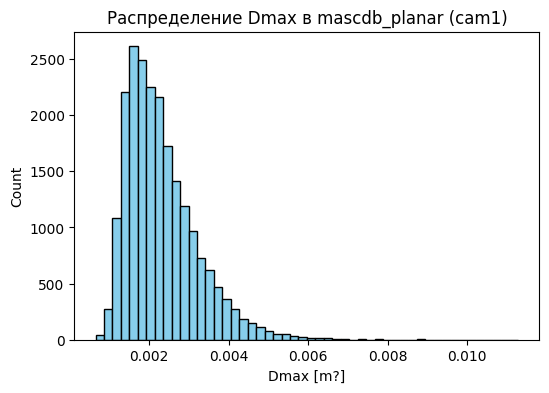

In [49]:
# проверка распределения размера среди отобранных снежинок
import matplotlib.pyplot as plt

dmax = mascdb_planar.cam1["Dmax"].values  # xarray -> numpy

plt.figure(figsize=(6,4))
plt.hist(dmax, bins=50, color="skyblue", edgecolor="k")
plt.xlabel("Dmax [m]")
plt.ylabel("Count")
plt.title("Распределение Dmax в mascdb_planar (cam1)")
plt.show()


In [132]:
# Выбираем максимальные по размеру снежинки (но они все равно будут маленькие)
mascdb_planar_big = mascdb_planar.select_max("cam1.Dmax", n=1500)

In [56]:
mascdb_planar_big.campaign

,start_time,end_time,latitude,longitude,altitude,n_triplets,n_events,event_duration_min,event_duration_mean,event_duration_max,total_event_duration,snowflake_class,riming_class,melting_class,precipitation_class
campaign,,,,,,,,,,,,,,,
APRES3-2016,2015-11-22 07:30:41.052000,2016-01-28 01:14:36.543442,-66.6628,140.0014,41.0,28,8,0 days 00:55:27.829043,0 days 16:20:33.035571125,1 days 21:59:18.178246,5 days 10:44:24.284569,{'planar_crystal': 28},"{'rimed': 13, 'graupel': 6, 'graupel-like': 4,...","{'dry': 27, 'melting': 1}","{'precip': 23, 'mixed': 3, 'blowing_snow': 2}"
APRES3-2017,2017-01-25 01:52:29.434493,2017-07-14 18:43:09.419509,-66.6628,140.0014,41.0,358,22,0 days 07:14:16.850570,1 days 05:01:01.925514227,5 days 06:19:51.658966,26 days 14:22:42.361313,{'planar_crystal': 358},"{'rimed': 255, 'densely_rimed': 51, 'graupel-l...","{'dry': 346, 'melting': 12}","{'precip': 163, 'mixed': 145, 'blowing_snow': 50}"
Davos-2015,2015-02-22 13:08:24.764348,2016-06-19 04:33:46.791085,46.8297,9.8093,2540.0,770,64,0 days 00:00:00,1 days 02:13:30.547386796,5 days 11:21:53.655179,69 days 22:24:35.032755,{'planar_crystal': 770},"{'rimed': 472, 'densely_rimed': 150, 'graupel-...","{'dry': 763, 'melting': 7}","{'precip': 580, 'mixed': 188, 'undefined': 2}"
Davos-2019,2019-03-01 01:03:36.164958,2019-03-26 09:34:33.078888,46.8450,9.8716,1512.0,58,11,0 days 00:46:07.554059,0 days 15:47:59.876449727,2 days 12:13:27.043601,7 days 05:47:58.640947,{'planar_crystal': 58},"{'rimed': 21, 'densely_rimed': 19, 'graupel-li...",{'dry': 58},"{'precip': 52, 'mixed': 6}"
ICEGENESIS-2021,2020-12-24 18:28:33.855832,2021-01-27 17:47:46.016212,47.0830,6.7922,1018.0,35,10,0 days 07:51:56.186937,1 days 09:21:21.734615,3 days 02:48:03.791906,13 days 21:33:37.346150,{'planar_crystal': 35},"{'rimed': 16, 'densely_rimed': 9, 'graupel': 7...","{'dry': 32, 'melting': 3}","{'precip': 31, 'mixed': 4}"
ICEPOP-2018,2018-02-22 18:18:54.929501,2018-03-21 03:25:47.660062,37.6652,128.6996,789.0,30,6,0 days 03:09:38.685807,0 days 17:55:17.065795666,1 days 14:41:51.137087,4 days 11:31:42.394774,{'planar_crystal': 30},"{'rimed': 15, 'densely_rimed': 8, 'graupel': 4...","{'dry': 29, 'melting': 1}","{'mixed': 16, 'precip': 14}"
ISLAS-2022,2022-04-01 20:45:50.667934,2022-04-01 20:45:50.667934,69.2985,16.0481,10.0,1,1,0 days 21:53:42.378358,0 days 21:53:42.378358,0 days 21:53:42.378358,0 days 21:53:42.378358,{'planar_crystal': 1},{'graupel': 1},{'dry': 1},{'mixed': 1}
Jura-2019,2019-11-17 11:59:42.925651,2020-03-29 16:48:48.082877,46.6702,6.3125,1045.0,47,21,0 days 05:45:03.295570,0 days 20:25:37.748417904,2 days 05:55:08.437601,17 days 20:58:12.716776,{'planar_crystal': 47},"{'rimed': 21, 'densely_rimed': 10, 'graupel': ...","{'dry': 41, 'melting': 6}","{'precip': 43, 'mixed': 4}"
Jura-2023,2023-02-01 08:28:14.460637,2023-03-11 03:29:36.101933,46.6702,6.3125,1045.0,16,3,0 days 11:36:46.575834,1 days 05:56:50.846007,1 days 19:04:28.587093,3 days 17:50:32.538021,{'planar_crystal': 16},"{'rimed': 12, 'densely_rimed': 3, 'graupel-lik...",{'dry': 16},"{'precip': 14, 'mixed': 2}"


In [133]:
# берем изображения только первой камеры
imgs = mascdb_planar_big.da.isel(cam_id=1)

In [134]:
imgs.shape

(1500, 1024, 1024)

In [ ]:
# превращает xarray в numpy.ndarray (очень долго)
imgs_np = mascdb_planar_big.da.isel(cam_id=1).values

In [13]:
type(imgs_np) 

numpy.ndarray

In [60]:
imgs_np.shape

(1500, 1024, 1024)

In [21]:
np.save("./data/planar_cam1_1024x1024.npy", imgs_np)

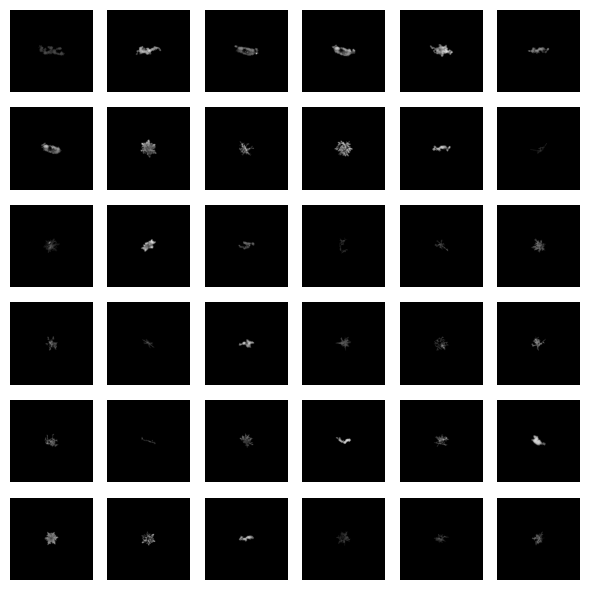

In [137]:
fig, axs = plt.subplots(6, 6, figsize=(6, 6))
for ax, img in zip(axs.flat, imgs_np[:36]):
    ax.imshow(img, cmap="gray")
    ax.axis("off")
plt.tight_layout()

In [138]:
import cv2
import numpy as np

def crop_and_resize(img, target_size=(50, 50), p=99):
    '''
    Функция выполняет следующие задачи:
    - сжимает изображения 1024 x 1024 до 50 x 50
    - решает проблему, что большинство отобранных снежинок очень маленькие, увеличивая их до размера контейнера (иначе бы большинство изображений было маленькими белыми точками)
    - увеличивает яркость
    '''
    # приведение к unit8
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)

    # бинаризация для отделения снежинки от фона (пиксели < 10 отображаются в 0)
    _, thresh = cv2.threshold(img, 10, 255, cv2.THRESH_BINARY)

    # поиск ненулевых пикселей и построение минимального прямоугольника, покрывающего их
    coords = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(coords)
    cropped = img[y:y+h, x:x+w]
    
    # квадратное поле
    size = max(w, h)
    square = np.zeros((size, size), dtype=cropped.dtype)
    
    # вставляем обрезанную снежинку в центр
    y_offset = (size - h) // 2
    x_offset = (size - w) // 2
    square[y_offset:y_offset+h, x_offset:x_offset+w] = cropped
    
    # resize до target_size
    resized = cv2.resize(square, target_size, interpolation=cv2.INTER_AREA)

    # нормализация
    resized = resized.astype(np.float32) / 255.0
    
    # усиление яркости
    hi = max(np.percentile(resized, p), 1e-6) # берется значение, меньше которого p% пикселей
    resized = resized / hi
    resized = np.clip(resized, 0, 1)
    
    return resized


In [126]:
import os
import cv2
import numpy as np
from tqdm import tqdm

TARGET_SIZE = (50, 50)

imgs_small = np.empty((imgs_np.shape[0], 50, 50), dtype=np.float32)

for i in range(imgs_np.shape[0]):
    imgs_small[i] = crop_and_resize(imgs_np[i], TARGET_SIZE, 95)


In [113]:
print(imgs_small.min(), imgs_small.max())

0.0 1.0


In [129]:
np.save("./data/planar_cam1_50x50.npy", imgs_small)


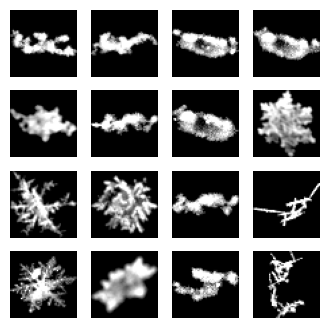

In [127]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 4, figsize=(4, 4))
for ax, img in zip(axs.flat, imgs_small[:16]):
    ax.imshow(img, cmap="gray")
    ax.axis("off")
plt.show()


In [102]:
import matplotlib.pyplot as plt

def show_batch(imgs, start, n=25):
    end = start + n
    side = int(np.sqrt(n))
    fig, axs = plt.subplots(side, side, figsize=(6, 6))
    for ax, img in zip(axs.flat, imgs[start:end]):
        ax.imshow(img, cmap="gray")
        ax.axis("off")
    plt.show()


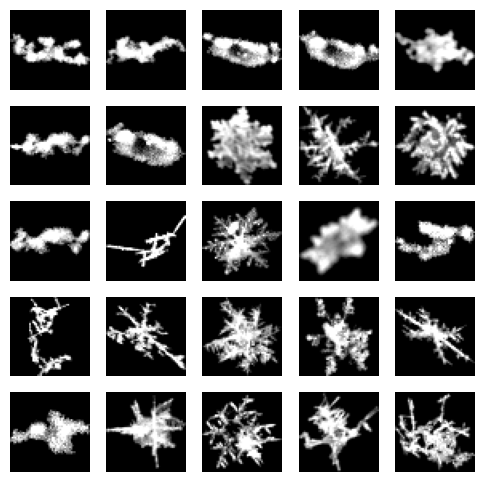

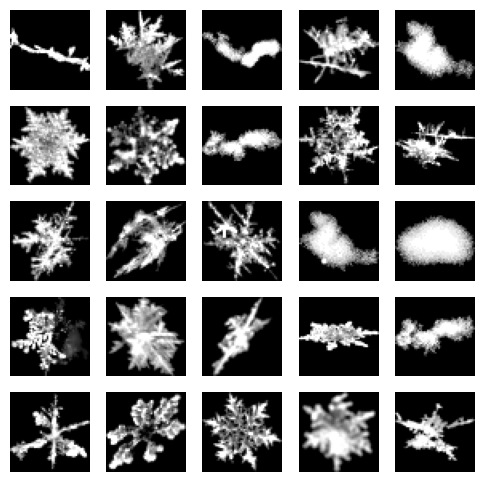

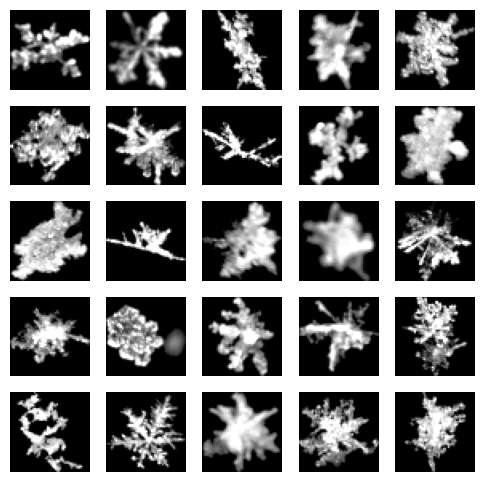

In [128]:
show_batch(imgs_small, start=0)
show_batch(imgs_small, start=25)
show_batch(imgs_small, start=1000)
